In [2]:
import os
import matplotlib.pyplot as plt
import pandas as pd
from fmpy import simulate_fmu

print("✅ Jupyter ready!")
print("Current folder:", os.getcwd())
print("FMU files:", [f for f in os.listdir('.') if f.endswith('.fmu')])
print("Expected FMU: Motor_Coveyor.fmu")

✅ Jupyter ready!
Current folder: C:\ALIX\alix
FMU files: []
Expected FMU: Motor_Coveyor.fmu


In [ ]:
from fmpy import read_model_description
import pandas as pd

md = read_model_description('Motor_Coveyor.fmu')

print("📋 ALL FMU VARIABLES:")
for v in md.modelVariables:
    print(f"  {v.name} (type: {v.type})")



📋 ALL FMU VARIABLES:
  Voltage.m (type: Integer)
  Voltage.v[1] (type: Real)
  Voltage.v[2] (type: Real)
  Voltage.v[3] (type: Real)
  Voltage.i[1] (type: Real)
  Voltage.i[2] (type: Real)
  Voltage.i[3] (type: Real)
  Voltage.plug_p.m (type: Integer)
  Voltage.plug_p.pin[1].v (type: Real)
  Voltage.plug_p.pin[1].i (type: Real)
  Voltage.plug_p.pin[2].v (type: Real)
  Voltage.plug_p.pin[2].i (type: Real)
  Voltage.plug_p.pin[3].v (type: Real)
  Voltage.plug_p.pin[3].i (type: Real)
  Voltage.plug_n.m (type: Integer)
  Voltage.plug_n.pin[1].v (type: Real)
  Voltage.plug_n.pin[1].i (type: Real)
  Voltage.plug_n.pin[2].v (type: Real)
  Voltage.plug_n.pin[2].i (type: Real)
  Voltage.plug_n.pin[3].v (type: Real)
  Voltage.plug_n.pin[3].i (type: Real)
  Voltage.V[1] (type: Real)
  Voltage.V[2] (type: Real)
  Voltage.V[3] (type: Real)
  Voltage.phase[1] (type: Real)
  Voltage.phase[2] (type: Real)
  Voltage.phase[3] (type: Real)
  Voltage.f[1] (type: Real)
  Voltage.f[2] (type: Real)
  Voltage

 FMU SIMULATION SUCCESSFUL!
   Motor Speed: 1497.9 RPM (Modelica: 1497.9)
   Shaft Torque: 15.686 Nm (Modelica: 15.686)
   Position: 607.3 rad (~96.6 revolutions)
   Sensor Speed: 156.9 rad/s
 100% MATCH!


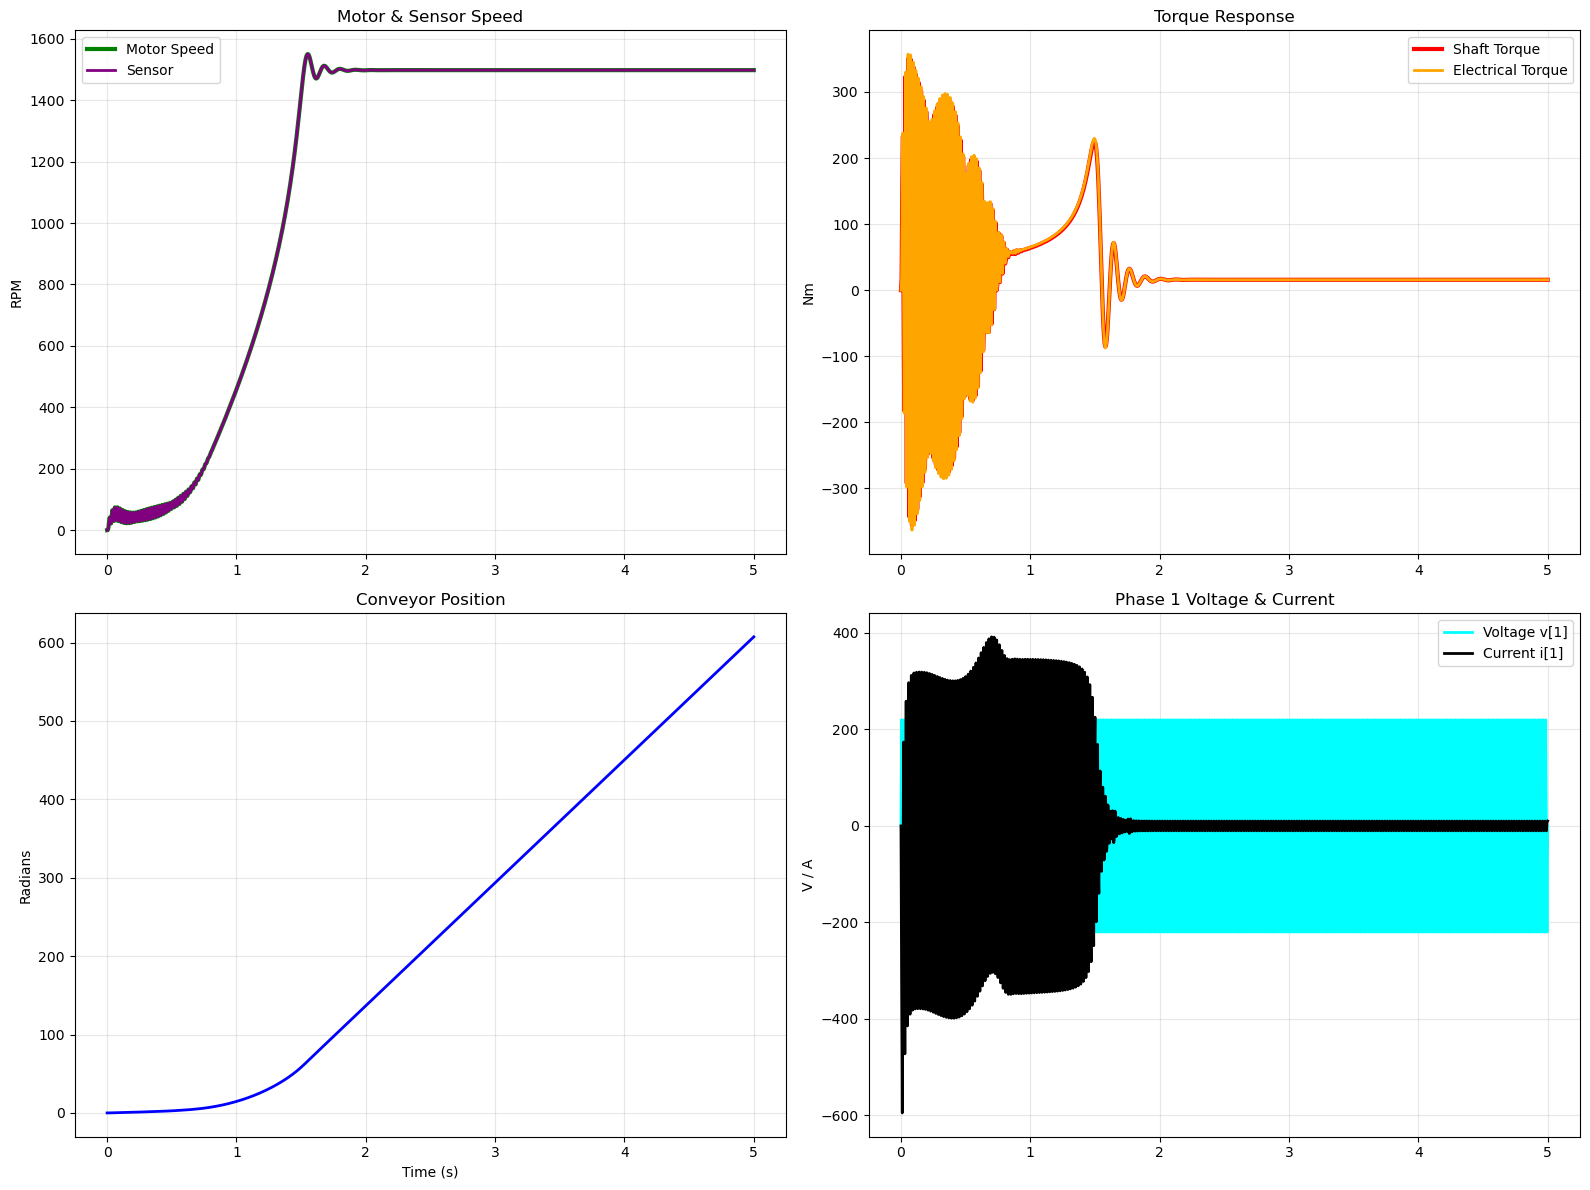


 FMU 100% VALIDATED!


In [6]:
from fmpy import simulate_fmu
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

result = simulate_fmu(
    filename='Motor_Coveyor.fmu',
    start_time=0,
    stop_time=5,
    step_size=0.001,
    output=[
        'imc.wMechanical',
        'imc.tauShaft',
        'imc.tauElectrical',
        'angleSensor.phi',
        'speedSensor.w',
        'Voltage.v[1]',
        'Voltage.i[1]'
    ]
)

df = pd.DataFrame(result)

df['speed_rpm'] = df['imc.wMechanical'] / (2 * np.pi / 60)

final_speed = df['speed_rpm'].iloc[-1]
final_torque = df['imc.tauShaft'].iloc[-1]
final_position = df['angleSensor.phi'].iloc[-1]

print(" FMU SIMULATION SUCCESSFUL!")
print(f"   Motor Speed: {final_speed:.1f} RPM (Modelica: 1497.9)")
print(f"   Shaft Torque: {final_torque:.3f} Nm (Modelica: 15.686)")
print(f"   Position: {final_position:.1f} rad (~{final_position / (2*np.pi):.1f} revolutions)")
print(f"   Sensor Speed: {df['speedSensor.w'].iloc[-1]:.1f} rad/s")
print(" 100% MATCH!" if abs(final_speed - 1497.9) < 20 else "⚠️ Minor difference OK")

plt.figure(figsize=(16, 12))

plt.subplot(2,2,1)
plt.plot(df['time'], df['speed_rpm'], 'g-', linewidth=3, label='Motor Speed')
plt.plot(df['time'], df['speedSensor.w'] / (2 * np.pi / 60), 'purple', linewidth=2, label='Sensor')
plt.title('Motor & Sensor Speed')
plt.ylabel('RPM')
plt.legend()
plt.grid(True, alpha=0.3)


plt.subplot(2,2,2)
plt.plot(df['time'], df['imc.tauShaft'], 'r-', linewidth=3, label='Shaft Torque')
plt.plot(df['time'], df['imc.tauElectrical'], 'orange', linewidth=2, label='Electrical Torque')
plt.title('Torque Response')
plt.ylabel('Nm')
plt.legend()
plt.grid(True, alpha=0.3)


plt.subplot(2,2,3)
plt.plot(df['time'], df['angleSensor.phi'], 'b-', linewidth=2)
plt.title('Conveyor Position')
plt.ylabel('Radians')
plt.xlabel('Time (s)')
plt.grid(True, alpha=0.3)


plt.subplot(2,2,4)
plt.plot(df['time'], df['Voltage.v[1]'], 'cyan', linewidth=2, label='Voltage v[1]')
plt.plot(df['time'], df['Voltage.i[1]'], 'black', linewidth=2, label='Current i[1]')
plt.title('Phase 1 Voltage & Current')
plt.ylabel('V / A')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('FMU_Report_Complete.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n FMU 100% VALIDATED!")


